[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/mhuertascompany/euclid-school-2026/blob/main/Y1/notebooks/1b-linear_regression_stochastic.ipynb)

# #1b Linear regression with neural network (stochastic version)

Our first implementation of a neural network is going to be the worst idea of when to use deep learning: trying to fit a linear problem!

But it is worth it, as it is the perfect example to show the common deep learning algorithm steps presented during the course, with the simplest architecture and loss you can imagine.

To still make it slightly interesting, we're going to apply it to the lHubble Law

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import torch

### Fix the seeds for reproducibility

In [2]:
seed = 10

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

## Step 1: Define your data

We are simulating some distance / velocity between 40 and 200Mpc, and an H0 of 70..., and some observational noise

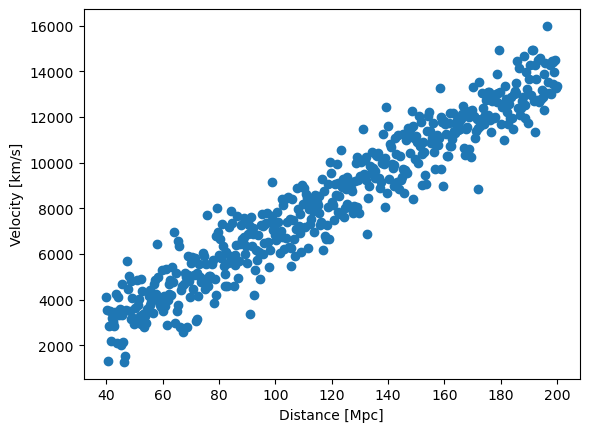

In [3]:
# True Hubble constant
H0 = 70  # km/s/Mpc

# Simulated galaxy distances
d = np.linspace(40, 200, 500)

# Recession velocities + observational/peculiar-velocity noise
v = H0 * d + np.random.normal(0, 1000, size=len(d))

plt.scatter(d, v)
plt.xlabel("Distance [Mpc]")
plt.ylabel("Velocity [km/s]")
plt.show()

### Normalisation

We see that our data needs normalisation.
we standardise our data by taking out the mean of the data, and dividing by the standard deviation

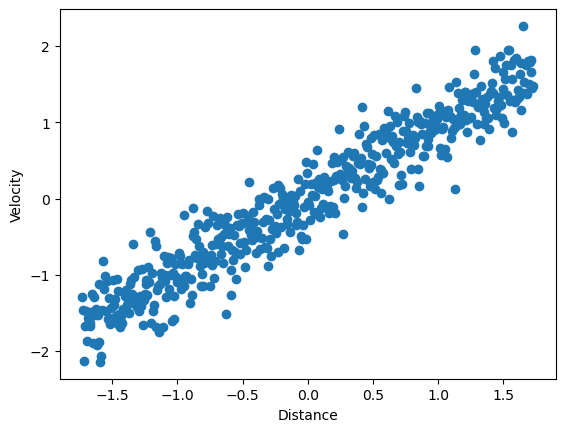

In [4]:
mean_d = np.mean(d)
std_d = np.std(d)
norm_d = (d - mean_d) / std_d

mean_v = np.mean(v)
std_v = np.std(v)
norm_v = (v - mean_v) / std_v

plt.scatter(norm_d, norm_v)
plt.xlabel("Distance")
plt.ylabel("Velocity")
plt.show()

## Creating the datasets
Now that we have pre-processed our data, we need to create our training, validation and testing sets.

We then transform them to torch tensors.

In [5]:
# set the number of samples per group
n_train_samples = int(0.8*len(norm_d))
n_validation_samples = int(0.1*len(norm_d))
n_test_samples = int(0.1*len(norm_d))

# randomise your data for random reprentation in each group
random_samples_ids = np.arange(len(norm_d))
np.random.shuffle(random_samples_ids)

# get the random ids
train_ids = random_samples_ids[:n_train_samples]
validation_ids = random_samples_ids[n_train_samples:n_train_samples+n_validation_samples]
test_ids = random_samples_ids[-n_test_samples:]

# create the sets
x_train = norm_d[train_ids]
y_train = norm_v[train_ids]

x_validation = norm_d[validation_ids]
y_validation = norm_v[validation_ids]

x_test = norm_d[test_ids]
y_test = norm_v[test_ids]


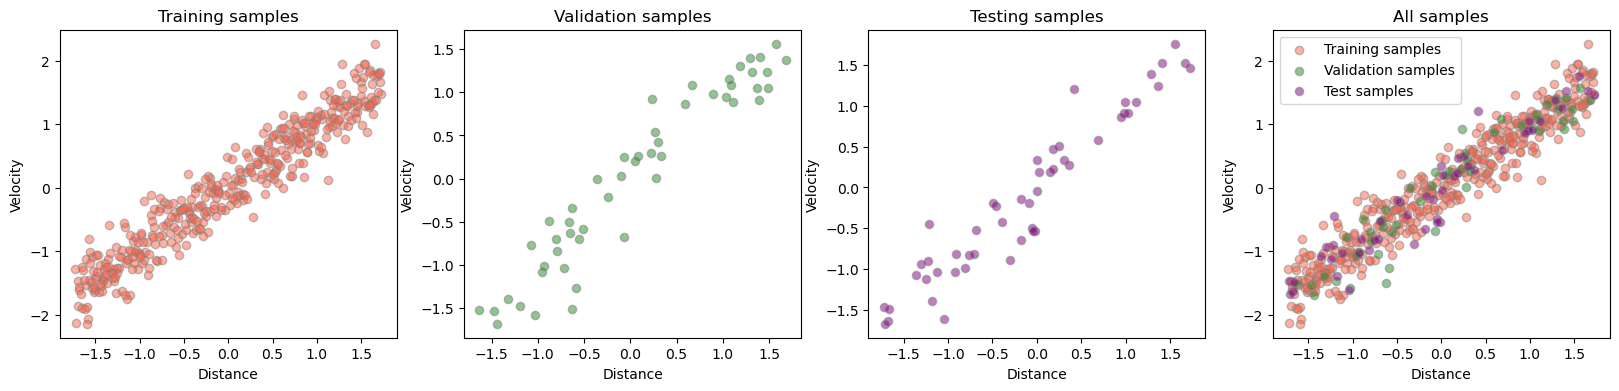

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
plt.subplots_adjust(wspace=0.2)

ax[0].scatter(x_train, y_train, c='tomato', alpha=0.5, edgecolors='gray', label='Training samples')
ax[1].scatter(x_validation, y_validation, c='forestgreen', alpha=0.5, edgecolors='gray', label='Validation samples')
ax[2].scatter(x_test, y_test, c='purple', alpha=0.5, edgecolors='gray', label='Test samples')

ax[3].scatter(x_train, y_train, c='tomato', alpha=0.5, edgecolors='gray', label='Training samples')
ax[3].scatter(x_validation, y_validation, c='forestgreen', alpha=0.5, edgecolors='gray', label='Validation samples')
ax[3].scatter(x_test, y_test, c='purple', alpha=0.5, edgecolors='gray', label='Test samples')
ax[3].legend()

ax[0].set_title('Training samples')
ax[1].set_title('Validation samples')
ax[2].set_title('Testing samples')
ax[3].set_title('All samples')
[axe.set_xlabel('Distance') for axe in ax]
[axe.set_ylabel('Velocity') for axe in ax];

We transform the numpy array to torch tensors

In [7]:
x_train = torch.unsqueeze(torch.from_numpy(x_train).float(), dim=1)
y_train = torch.unsqueeze(torch.from_numpy(y_train).float(), dim=1)

x_validation = torch.unsqueeze(torch.from_numpy(x_validation).float(), dim=1)
y_validation = torch.unsqueeze(torch.from_numpy(y_validation).float(), dim=1)

x_test = torch.unsqueeze(torch.from_numpy(x_test).float(), dim=1)
y_test = torch.unsqueeze(torch.from_numpy(y_test).float(), dim=1)

In [8]:
print(f'train shape: {x_train.shape}')
print(f'validation shape: {x_validation.shape}')
print(f'test shape: {x_test.shape}')

train shape: torch.Size([400, 1])
validation shape: torch.Size([50, 1])
test shape: torch.Size([50, 1])


## Step 3: Defining the model
Our model here is the simplest model possible: it's one neuron, that is going to do:

$y = w_0*x + b_0$, where y is our velocity prediction, $w_0$ is the unique weight of our model and $b_0$ the unique bias, 

To do so, we use torch, with a Linear layer, with one input (the distance) and one output (the velocity)

In [9]:
class LinearRegressionModel(torch.nn.Module):

    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1, 1)  # One in and one out

    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

In [10]:
our_model = LinearRegressionModel()
total_params = sum(p.numel() for p in our_model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 2


## Step 4: Define Loss and optimizer
We also need to define our loss function and the gradient descent algorithm. We are going to use the mean square error loss, and the stochastic gradient descent with a learning rate of 1e-2:

In [11]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(our_model.parameters(), lr = 0.01)

## Step 5-9: Training
We are now ready to train. we define a number of epochs (15), a batch size (32)and loop through these epochs, training batch by batch:

For each epoch:
- We re-shuffle the training set to get different batch orders

- we create the batch for each step

- Step 5: we feed the gene expression data to our model which output a prediction.

- Step 6: With this prediction and the corresponding ground truth, we compute the loss.

- Step 7: with the loss, we compute the gradient And we apply the gradeints to update the weights of our model.

- Step 8: We do step 5 and 6 on the validation data.

- Step 9: loop.



We define a much lower number of epochs than in the first case, but it's because we are training by batch, so we are training more than one per epoch!

In [12]:
batch_size = 64
n_epochs = 30

In [13]:

losses_steps = []
losses_epochs = []
val_losses = []
val_steps = []

for epoch in range(n_epochs):
    loss_epoch = 0

    #shuffle the trainig data each epoch for better stochasticity
    indices = torch.randperm(n_train_samples)
    x_shuffled = x_train[indices]
    y_shuffled = y_train[indices]

    # loop through the dataset per batch
    our_model.train()  # when there is a difference in training / eval / test, for example dropout, 
    for i, start_idx in enumerate(range(0, n_train_samples, batch_size)):
        
        # take only the current batch
        end_idx = start_idx + batch_size
        x_batch = x_shuffled[start_idx:end_idx]
        y_batch = y_shuffled[start_idx:end_idx]

        # Step 5: use the model to predict on the epoch
        pred_y = our_model(x_batch)

        # Step 6: Compute the taining loss on the epoch and log it
        loss = criterion(pred_y, y_batch)
        loss_epoch += loss.detach().numpy()
        losses_steps.append(loss.detach().numpy())

        # Zero gradients (not accumulate)
        optimizer.zero_grad()
        
        # Step 7 compute the gradients and apply the gradients to optimise
        loss.backward()
        optimizer.step()
        
    # Compute the mean loss on the epoch
    losses_epochs.append(loss_epoch / i)

    # Step 8: same in validation (without 7), after each epoch
    our_model.eval()
    pred_y_validation = our_model(x_validation)
    val_loss = criterion(pred_y_validation, y_validation)
    val_steps.append(len(losses_steps))  # current global step
    val_losses.append(val_loss.detach().numpy())



## Plot the training loss
Now that our model is trained, we can compute the loss, first diagnistic to see if our model is learning.

We plot the loss per step (on each batch, left) and the mean per epoch (right)

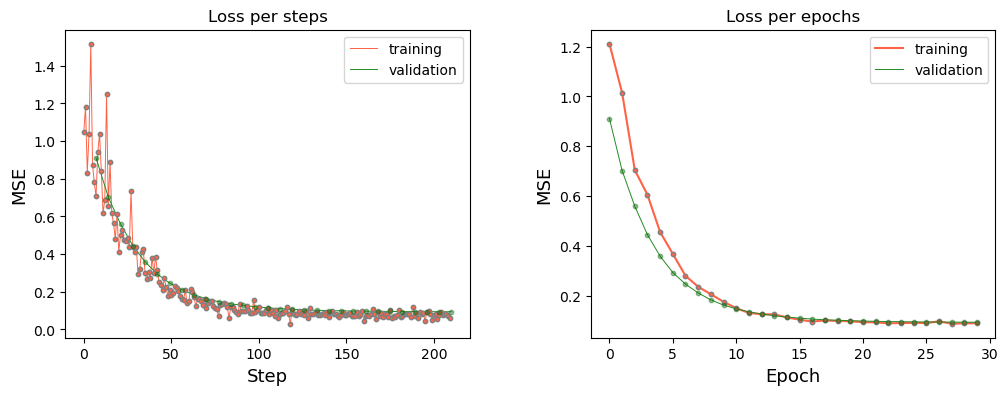

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.3)
ax[0].scatter(np.arange(len(losses_steps)), losses_steps, alpha=1, s=10, c='tomato', zorder=5, edgecolors='gray')
ax[0].plot(np.arange(len(losses_steps)), losses_steps, c='tomato', lw=.7, label='training')
ax[0].scatter(val_steps, val_losses, alpha=0.4, s=10, c='darkgreen', zorder=5)
ax[0].plot(val_steps, val_losses, c='forestgreen', lw=.7, label='validation')


ax[1].scatter(np.arange(len(losses_epochs)), losses_epochs, alpha=1, s=10, c='tomato', zorder=5, edgecolors='gray')
ax[1].plot(np.arange(len(losses_epochs)), losses_epochs, c='tomato', label='training')
ax[1].scatter(np.arange(len(losses_epochs)), val_losses, alpha=0.4, s=10, c='darkgreen', zorder=5)
ax[1].plot(np.arange(len(losses_epochs)), val_losses, c='forestgreen', lw=.7, label='validation')

[axe.set_ylabel('MSE', fontsize=13) for axe in ax]
ax[0].set_xlabel('Step', fontsize=13)
ax[1].set_xlabel('Epoch', fontsize=13)

ax[0].set_title('Loss per steps')
ax[1].set_title('Loss per epochs')
ax[0].legend()
ax[1].legend();

We see that per step, even if the loss decrease, it is more chaotic. This is due to the stochasticity, with certain batch bein harder to predict, leadnign to a greater loss.

But per epoch, we have something much smoother, showing how the model is able to predict the full dataset after seeing the full training dataset

## Step 10: Prediction on the testing set
We can now see what our model is predicting given gene expression. We show the results on the training set (left) and on the testing set (right).

In [15]:
our_model.eval()
pred_on_train = our_model(x_train)
pred_on_test = our_model(x_test)

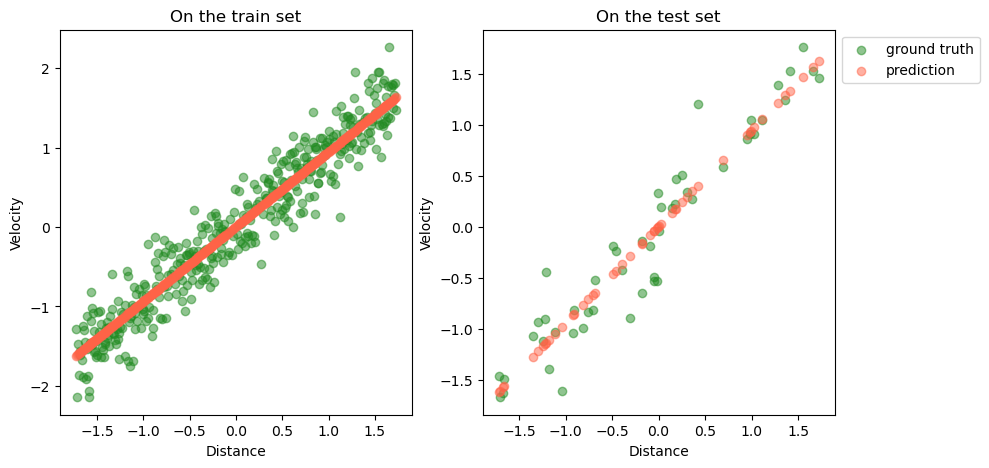

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(x_train, y_train, color='forestgreen', alpha=0.5, label='ground truth')
ax[0].scatter(x_train, pred_on_train.detach().numpy(), color='tomato', alpha=0.5, label='prediction')

ax[1].scatter(x_test, y_test, color='forestgreen', alpha=0.5, label='ground truth')
ax[1].scatter(x_test, pred_on_test.detach().numpy(), color='tomato', alpha=0.5, label='prediction')

ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left')

[axe.set_xlabel('Distance') for axe in ax]
[axe.set_ylabel('Velocity') for axe in ax]

ax[0].set_title('On the train set')
ax[1].set_title('On the test set');


We see that our model as learnt a linear regression trying to fit our more or less linear data. Our model can't do more: it has only one neuron, without activation. It's a pure linear fit!

We can actually print the weights of the model:

In [17]:
w_0 = our_model.linear.weight
b_0 = our_model.linear.bias

In [18]:
print(f'w_0: {w_0.data[0][0]}')
print(f'b_0: {b_0.data[0]}')

w_0: 0.9414288997650146
b_0: 0.004569277632981539


In [19]:
H0 = w_0 * std_v / std_d
print(f'H0: {H0.detach().numpy()[0]}')


H0: [67.9461]


## Metrics
The last step of the classic deep learning algorithm is to quantify the learning on metrics (usually different than the loss (becasue metrics are not always differentiable...))
Here the classic metric would be the MSE, so we don't have more to do!